# Módulo D — Mapa de idoneidad de un país

En vez de enfocarse en un solo lugar, este módulo explora todo un país y crea un mapa que destaca las áreas más prometedoras para el cultivo de té, además de proporcionar una lista de las ubicaciones más idóneas. Por ejemplo, Costa Rica.

**Requisito**: el modelo que se entrenó en el B.3 (modelo_teasuitability_real.pkl) y los rasters de WorldClim que se descargaron en el A.1.

## 1. Instalar librerías

In [1]:
!pip install lightgbm rasterio -q   # lightgbm y rasterio: cargar el modelo y leer los mapas

## 2. Montar Drive y cargar el modelo de datos reales (celda robusta)

In [2]:
import os                       # comprobar rutas y estado del Drive
from pathlib import Path        # manejar rutas de forma segura
import joblib                   # cargar el modelo guardado (.pkl)
import pandas as pd             # tablas de datos
# clases necesarias para que joblib pueda reconstruir el modelo guardado:
from lightgbm import LGBMClassifier                                  # modelo LightGBM
from sklearn.ensemble import (RandomForestClassifier,                # modelo Random Forest
                              StackingClassifier)                     # el stacking
from sklearn.linear_model import LogisticRegression                  # meta-modelo del stacking
from sklearn.pipeline import make_pipeline                           # encadenar escalado + SVM
from sklearn.preprocessing import StandardScaler                     # estandarizar
from sklearn.svm import SVC                                          # modelo SVM
import warnings; warnings.filterwarnings('ignore')                   # oculta avisos

# Montar el Drive solo si aún no lo está (evita montarlo dos veces)
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

# Carpetas del proyecto (las mismas de los módulos anteriores)
CARPETA_BASE = Path('/content/drive/MyDrive/TFM_TeaSuitability')
CARPETA_CLIMA = CARPETA_BASE / 'worldclim'
RUTA_MODELO = CARPETA_BASE / 'modelo_teasuitability_real.pkl'

# Si no está el modelo, se avisa mostrando qué hay en la carpeta
if not RUTA_MODELO.exists():
    print('No encuentro el modelo en:', RUTA_MODELO)
    for elemento in sorted(CARPETA_BASE.glob('*')):
        print('  -', elemento.name)
    raise FileNotFoundError('Falta el modelo. Ejecuta primero el B.3.')

modelo = joblib.load(RUTA_MODELO)                       # modelo entrenado (del B.3)
dataset = pd.read_csv(CARPETA_BASE / 'dataset_master.csv')  # para la mediana del pH
print('Modelo cargado. Variables que espera:', modelo.n_features_in_)

Mounted at /content/drive
Modelo cargado. Variables que espera: 7


# 3. Importaciones y configuración

In [3]:
import numpy as np                              # cálculo numérico y rejillas
import rasterio                                 # leer y muestrear los rasters
from rasterio.warp import transform as warp_transform  # transformar coordenadas (pH)
import matplotlib.pyplot as plt                 # dibujar el mapa

# Las 8 variables del modelo (mismo orden que en el entrenamiento del B.3)
COLUMNAS = [
    'temperatura_media',        # bio1: temperatura media anual
    'rango_diurno',             # bio2: diferencia entre la máxima del día y la mínima nocturna
    'precipitacion_anual',      # bio12: lluvia total anual
    'estacionalidad_precip',    # bio15: variación de la lluvia entre estaciones
    'precip_trimestre_seco',    # bio17: lluvia en la estación seca
    'elevacion',                # altitud del terreno
    'ph_suelo',                 # pH del suelo (SoilGrids)
]
# las 7 que se muestrean de los rasters locales (el pH viene de SoilGrids)
COLUMNAS_CLIMA = [c for c in COLUMNAS if c != 'ph_suelo']

# variable descriptiva -> archivo WorldClim (descargados en el A.1)
CAPAS = {
    'temperatura_media':      CARPETA_CLIMA / 'wc2.1_5m_bio_1.tif',   # bio1
    'rango_diurno':           CARPETA_CLIMA / 'wc2.1_5m_bio_2.tif',   # bio2
    'precipitacion_anual':    CARPETA_CLIMA / 'wc2.1_5m_bio_12.tif',  # bio12
    'estacionalidad_precip':  CARPETA_CLIMA / 'wc2.1_5m_bio_15.tif',  # bio15
    'precip_trimestre_seco':  CARPETA_CLIMA / 'wc2.1_5m_bio_17.tif',  # bio17
    'elevacion':              CARPETA_CLIMA / 'wc2.1_5m_elev.tif',    # elevación
}

# límites geográficos de Costa Rica (lon_min, lat_min, lon_max, lat_max)
LIMITES_CR = (-86.0, 8.0, -82.5, 11.3)

# URL del mapa de pH de SoilGrids (media, capa superficial 0-5 cm)
URL_PH = ('/vsicurl/https://files.isric.org/soilgrids/latest/data/'
          'phh2o/phh2o_0-5cm_mean.vrt')

## 4. Funciones del mapa de idoneidad

In [4]:
def crear_rejilla(limites, paso=0.05):
    """
    Crea una rejilla regular de puntos que cubre un área geográfica.

    Parameters
    ----------
    limites : tuple of float
        Rectángulo a cubrir (lon_min, lat_min, lon_max, lat_max).
    paso : float, optional
        Separación entre puntos en grados (0.05 ~ 5.5 km). Por defecto 0.05.

    Returns
    -------
    pandas.DataFrame
        Tabla con columnas 'lon' y 'lat' de todos los puntos de la rejilla.

    Examples
    --------
    >>> r = crear_rejilla((-86, 8, -82.5, 11.3), paso=0.5)
    >>> {'lon', 'lat'}.issubset(r.columns)
    True
    """
    lon_min, lat_min, lon_max, lat_max = limites   # se desempaqueta el rectángulo
    lons = np.arange(lon_min, lon_max, paso)        # longitudes de la rejilla
    lats = np.arange(lat_min, lat_max, paso)        # latitudes de la rejilla
    malla = [(lo, la) for la in lats for lo in lons]  # todas las combinaciones
    return pd.DataFrame(malla, columns=['lon', 'lat'])


def muestrear_rejilla(rejilla, capas, columnas_clima):
    """
    Añade a cada punto de la rejilla sus variables climáticas (WorldClim).

    Los puntos fuera de cobertura (mar) quedan con NaN y se eliminan, con lo
    que la forma del país emerge de manera natural.

    Parameters
    ----------
    rejilla : pandas.DataFrame
        Puntos con columnas 'lon' y 'lat'.
    capas : dict of {str: pathlib.Path}
        Diccionario {nombre_variable: ruta_del_raster}.
    columnas_clima : list of str
        Nombres de las variables que se muestrean de los rasters.

    Returns
    -------
    pandas.DataFrame
        La rejilla con una columna por variable, sin los puntos sin datos.
    """
    coordenadas = list(zip(rejilla['lon'], rejilla['lat']))  # pares (lon, lat)
    r = rejilla.copy()                                        # copia para no tocar la original
    for nombre in columnas_clima:
        with rasterio.open(capas[nombre]) as raster:          # abre y cierra el raster solo
            r[nombre] = [
                float(c[0]) if (raster.nodata is None or c[0] != raster.nodata)
                else np.nan                                   # sin dato -> faltante
                for c in raster.sample(coordenadas)
            ]
    return r.dropna().reset_index(drop=True)                  # quita el mar


def muestrear_ph_rejilla(rejilla, url=URL_PH):
    """
    Añade el pH del suelo (SoilGrids) a cada punto de la rejilla.

    SoilGrids usa la proyección Homolosine, así que las coordenadas se
    transforman antes de muestrear. Los valores vienen multiplicados por 10.

    Parameters
    ----------
    rejilla : pandas.DataFrame
        Puntos con columnas 'lon' y 'lat'.
    url : str, optional
        Ruta al GeoTIFF/VRT de pH de SoilGrids.

    Returns
    -------
    list of float
        pH del suelo en cada punto (NaN si no hay dato).
    """
    with rasterio.open(url) as src:
        # transformar lon/lat -> proyección de SoilGrids (Homolosine)
        xs, ys = warp_transform('EPSG:4326', src.crs,
                                list(rejilla['lon']), list(rejilla['lat']))
        valores = []
        for celda in src.sample(list(zip(xs, ys))):
            v = float(celda[0])
            valores.append(np.nan if v == src.nodata else v / 10.0)  # pH x10
    return valores


def predecir_idoneidad(modelo, rejilla, columnas):
    """
    Predice la probabilidad de idoneidad de cada punto de la rejilla.

    Parameters
    ----------
    modelo : estimator
        Modelo entrenado con método predict_proba.
    rejilla : pandas.DataFrame
        Rejilla ya muestreada (con las 8 variables).
    columnas : list of str
        Nombres de las variables, en el orden del entrenamiento.

    Returns
    -------
    pandas.DataFrame
        La rejilla con una columna nueva 'prob_idoneidad'.
    """
    r = rejilla.copy()
    r['prob_idoneidad'] = modelo.predict_proba(r[columnas])[:, 1]  # prob. de té
    return r


def graficar_mapa(rejilla, titulo):
    """
    Dibuja el mapa de idoneidad (verde = apto, rojo = no apto).

    Parameters
    ----------
    rejilla : pandas.DataFrame
        Rejilla con 'lon', 'lat' y 'prob_idoneidad'.
    titulo : str
        Título que se mostrará sobre el mapa.

    Returns
    -------
    None
        Solo dibuja la figura.
    """
    plt.figure(figsize=(8, 8))
    # cada punto se colorea según su probabilidad de idoneidad
    grafico = plt.scatter(rejilla['lon'], rejilla['lat'],
                          c=rejilla['prob_idoneidad'], cmap='RdYlGn',
                          s=10, vmin=0, vmax=1)
    plt.colorbar(grafico, label='Probabilidad de idoneidad')
    plt.xlabel('Longitud'); plt.ylabel('Latitud')
    plt.title(titulo)
    plt.tight_layout(); plt.show()

## 5. Ejecución: rejilla, clima y pH

Primero, se establece la rejilla de Costa Rica y se recopilan las variables climáticas a través de WorldClim, además del pH del suelo utilizando SoilGrids. En caso de que no se disponga del pH, se sustituye con la mediana del conjunto de datos, siguiendo la misma estrategia que se aplicó en el A.1.

In [5]:
# 1- rejilla de puntos que cubre Costa Rica
rejilla = crear_rejilla(LIMITES_CR, paso=0.05)
print('Puntos de la rejilla:', len(rejilla))

# 2- variables climáticas (los puntos en el mar se descartan aquí)
rejilla = muestrear_rejilla(rejilla, CAPAS, COLUMNAS_CLIMA)
print('Puntos en tierra (con clima):', len(rejilla))

# 3- pH del suelo; si SoilGrids falla, se usa la mediana del dataset
try:
    rejilla['ph_suelo'] = muestrear_ph_rejilla(rejilla)
except Exception as error:
    print('(SoilGrids no disponible; se usa la mediana del dataset)', error)
    rejilla['ph_suelo'] = np.nan
rejilla['ph_suelo'] = rejilla['ph_suelo'].fillna(dataset['ph_suelo'].median())
print('pH añadido. Media en la rejilla:', round(rejilla['ph_suelo'].mean(), 2))

Puntos de la rejilla: 4690
Puntos en tierra (con clima): 2405
pH añadido. Media en la rejilla: 5.48


## 6. Ejecución: predecir la idoneidad de todo el país

In [6]:
rejilla = predecir_idoneidad(modelo, rejilla, COLUMNAS)
print('Idoneidad media del país:', round(rejilla['prob_idoneidad'].mean(), 3))
print('Puntos de idoneidad Alta (>0.75):', int((rejilla['prob_idoneidad'] > 0.75).sum()))

Idoneidad media del país: 0.462
Puntos de idoneidad Alta (>0.75): 655


## 7. Mapa de idoneidad de Costa Rica

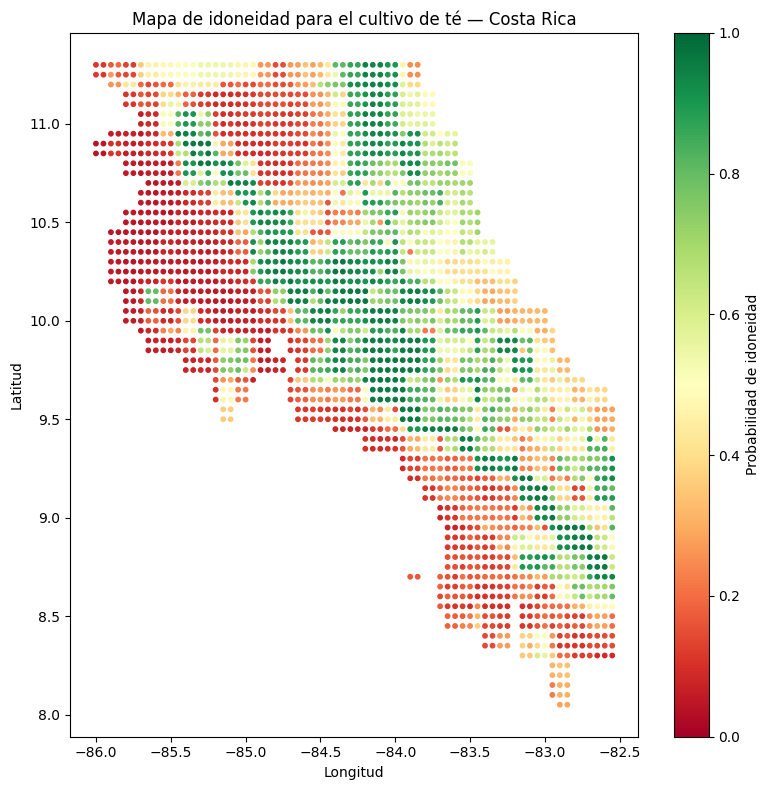

In [7]:
graficar_mapa(rejilla, 'Mapa de idoneidad para el cultivo de té — Costa Rica')

## 8. Las mejores zonas (¿dónde cultivar té?)

Se organizan los puntos según su idoneidad y se presentan las diez mejores ubicaciones junto con sus coordenadas, que es la respuesta directa a la pregunta de dónde es mejor cultivar.

In [8]:
mejores = rejilla.sort_values('prob_idoneidad', ascending=False).head(10)
print('TOP 10 ubicaciones más aptas para el té en Costa Rica:')
print(mejores[['lon', 'lat', 'temperatura_media', 'precipitacion_anual',
               'ph_suelo', 'prob_idoneidad']].round(2).to_string(index=False))

TOP 10 ubicaciones más aptas para el té en Costa Rica:
   lon   lat  temperatura_media  precipitacion_anual  ph_suelo  prob_idoneidad
-84.20 10.10              17.67               2452.0       5.2            0.97
-84.20 10.15              17.67               2452.0       5.4            0.97
-84.10  9.70              17.41               2378.0       5.2            0.97
-84.75 10.30              19.25               2761.0       5.4            0.97
-85.30 10.80              20.79               2833.0       5.4            0.97
-84.40 10.25              18.62               3224.0       5.4            0.97
-85.25 10.80              20.79               2833.0       5.5            0.96
-84.35 10.30              18.62               3224.0       5.3            0.96
-85.10 10.70              21.04               2766.0       5.4            0.96
-84.00  9.80              18.10               2184.0       5.4            0.96


## 9. Guardar los resultados

In [9]:
RUTA_MAPA = CARPETA_BASE / 'mapa_idoneidad_costarica.csv'
rejilla.to_csv(RUTA_MAPA, index=False)   # guardar sin la columna de índice
print('GUARDADO en:', RUTA_MAPA)
print('Forma:', rejilla.shape)

# comprobación final: confirmar que el archivo existe en el Drive
print('¿Archivo creado?', RUTA_MAPA.exists())

GUARDADO en: /content/drive/MyDrive/TFM_TeaSuitability/mapa_idoneidad_costarica.csv
Forma: (2405, 10)
¿Archivo creado? True
